# 01 - EDA

Exploracion inicial del dataset de celulas sanguineas.

In [1]:
from pathlib import Path
import os
import sys
import subprocess


def find_project_root() -> Path:
    env_root = os.environ.get("PROJECT_ROOT")
    starts = [Path(env_root).resolve()] if env_root else []
    starts.append(Path.cwd().resolve())
    checked = []
    for start in starts:
        checked.extend([start, *start.parents])
        for base in [start, *start.parents]:
            checked.extend(base.glob("dl-semana6-*"))
    seen = set()
    for candidate in checked:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "src" / "train.py").is_file() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("No se encontro la raiz del proyecto. Ejecuta Jupyter desde el repo o define PROJECT_ROOT.")


ROOT = find_project_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from utils import resolve_data_dir

data_env = os.environ.get("DATA_DIR")
results_env = os.environ.get("RESULTS_DIR")
DATA_DIR = resolve_data_dir(Path(data_env) if data_env else ROOT / "data" / "dataset")
RESULTS_DIR = Path(results_env).expanduser().resolve() if results_env else ROOT / "results"
FAST_DEV_RUN = os.environ.get("FAST_DEV_RUN", "0") == "1"
print(f"ROOT={ROOT}")
print(f"DATA_DIR={DATA_DIR}")
print(f"FAST_DEV_RUN={FAST_DEV_RUN}")

ROOT=C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas
DATA_DIR=C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas\data\dataset
FAST_DEV_RUN=False


In [2]:
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image

train_dir = DATA_DIR / "images" / "TRAIN"
test_dir = DATA_DIR / "images" / "TEST"
classes = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
classes

['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

In [3]:
counts = {
    split: {cls: len(list((DATA_DIR / "images" / split / cls).glob("*.jpeg"))) for cls in classes}
    for split in ["TRAIN", "TEST"]
}
counts

{'TRAIN': {'EOSINOPHIL': 2497,
  'LYMPHOCYTE': 2483,
  'MONOCYTE': 2478,
  'NEUTROPHIL': 2499},
 'TEST': {'EOSINOPHIL': 623,
  'LYMPHOCYTE': 620,
  'MONOCYTE': 620,
  'NEUTROPHIL': 624}}

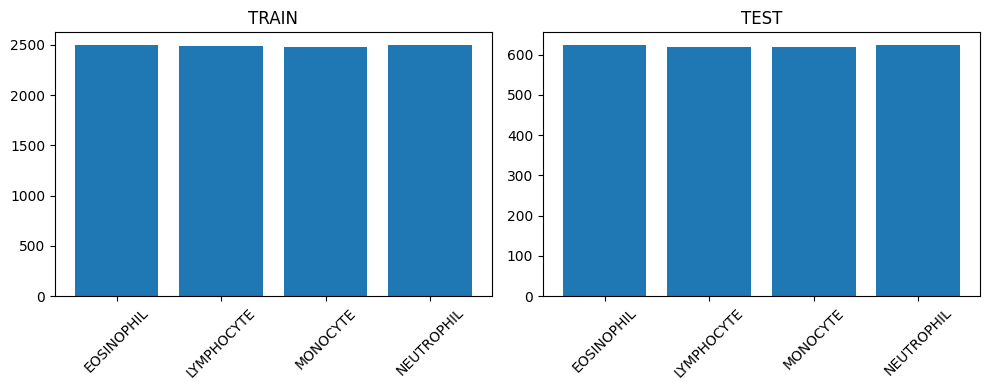

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, split in zip(axes, ["TRAIN", "TEST"]):
    ax.bar(counts[split].keys(), counts[split].values())
    ax.set_title(split)
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

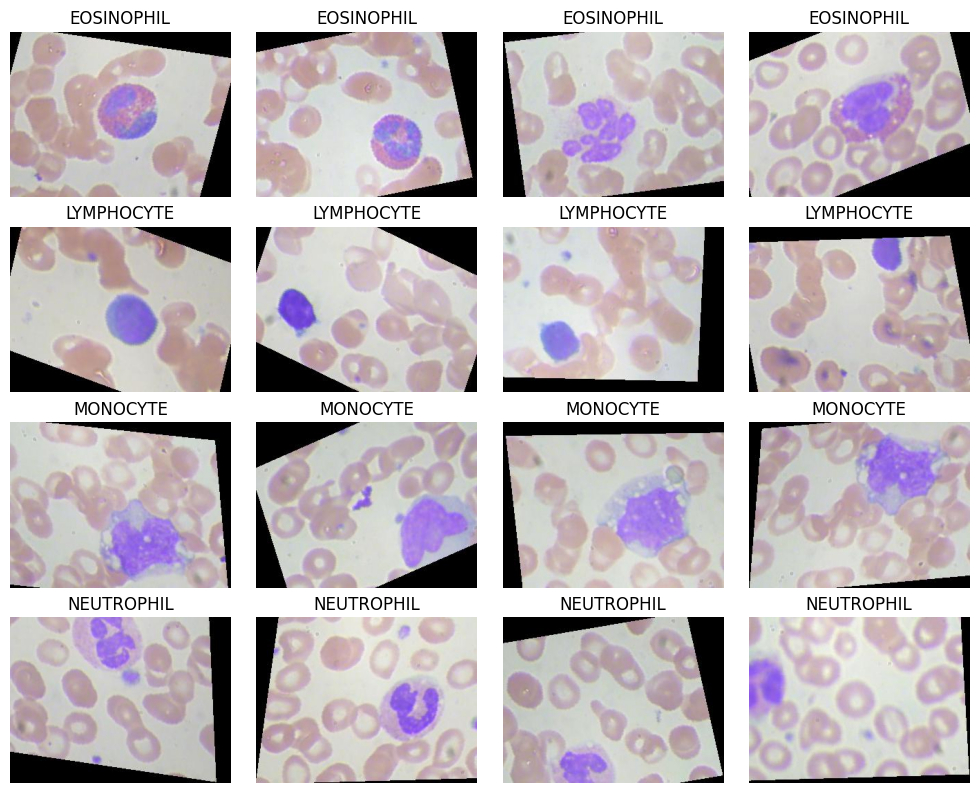

In [5]:
fig, axes = plt.subplots(len(classes), 4, figsize=(10, 8))
for row, cls in enumerate(classes):
    image_paths = list((train_dir / cls).glob("*.jpeg"))[:4]
    for col, ax in enumerate(axes[row]):
        ax.axis("off")
        if col < len(image_paths):
            ax.imshow(Image.open(image_paths[col]))
            ax.set_title(cls)
fig.tight_layout()